# BAH Dataset — ViT Training
Reads configuration from `config.toml`, trains a Vision Transformer on segmented body frames, evaluates on validation after every epoch, runs inference on the test split, and saves the best weights.

In [13]:
import os, random, warnings
from pathlib import Path
from collections import defaultdict

import toml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
)
from vit_pytorch import ViT
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# ── Load config ──────────────────────────────────────────────────────────────
CFG = toml.load('config.toml')

SPLIT_FRAMES_DIR = Path(CFG['data']['split_frames_dir'])
SEG_DIR          = Path(CFG['data']['segmented_dir'])
NUM_CLASSES      = CFG['data']['num_classes']
CLASS_NAMES      = CFG['data']['class_names']

IMAGE_SIZE  = CFG['image']['image_size']
PATCH_SIZE  = CFG['image']['patch_size']
IMG_MEAN    = CFG['image']['mean']
IMG_STD     = CFG['image']['std']

EPOCHS      = CFG['training']['epochs']
BATCH_SIZE  = CFG['training']['batch_size']
LR                   = CFG['training']['learning_rate']
WD                   = CFG['training']['weight_decay']
NUM_WORKERS          = CFG['training']['num_workers']
SEED                 = CFG['training']['seed']
PATIENCE             = CFG['training']['early_stopping_patience']
FRAME_SUBSAMPLE_EVERY = CFG['training'].get('frame_subsample_every', 1)

WEIGHTS_DIR  = Path(CFG['output']['weights_dir'])
WEIGHTS_NAME = CFG['output']['weights_name']
LAST_NAME    = CFG['output']['last_name']
SAVE_LAST    = CFG['output']['save_last']

# ── Reproducibility ───────────────────────────────────────────────────────────
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Device ────────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print('Config loaded from config.toml')
print(f'Device : {DEVICE}')
print(f'Epochs : {EPOCHS}  |  Batch : {BATCH_SIZE}  |  LR : {LR}')


Config loaded from config.toml
Device : mps
Epochs : 20  |  Batch : 64  |  LR : 0.0003


Computing segmented-frame coverage (may take a moment)...

Split           Total    Class 0    Class 1    Segmented   Missing
------------------------------------------------------------------------
train         501,970    425,468     76,502      501,226       744
val            79,538     65,556     13,982       79,476        62
test          335,110    269,361     65,749      334,282       828


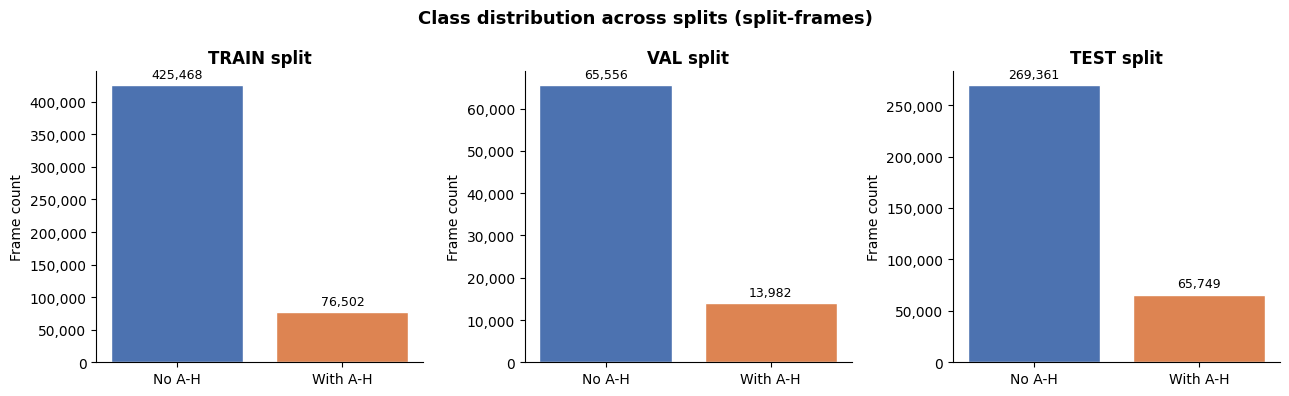

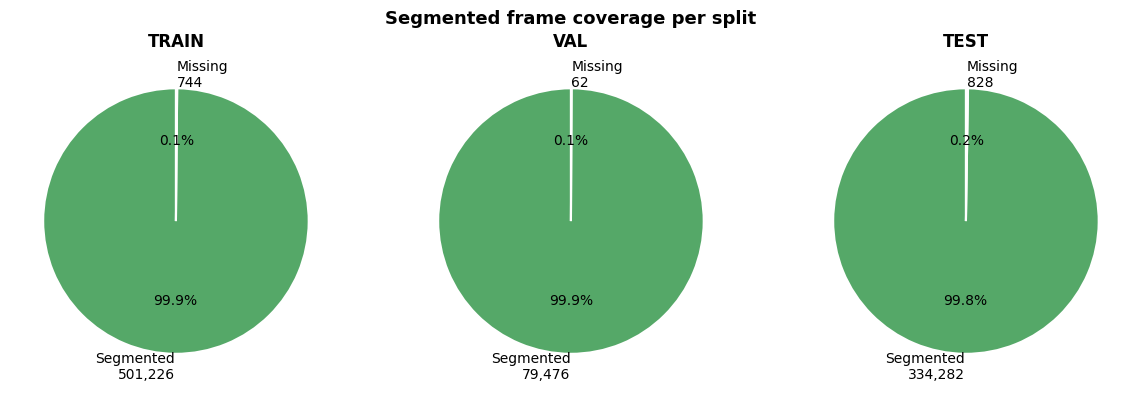


Unique video folders per split:
  train : 778 videos
  val   : 124 videos
  test  : 525 videos


In [14]:
# ── Helper: parse split-frames txt ───────────────────────────────────────────
def load_frame_split(split: str) -> pd.DataFrame:
    path = SPLIT_FRAMES_DIR / f'{split}.txt'
    rows = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            frame_path, label = line.rsplit(',', 1)
            rows.append({'frame_path': frame_path, 'label': int(label)})
    df = pd.DataFrame(rows)
    df['video_folder'] = df['frame_path'].apply(lambda p: str(Path(p).parent))
    df['frame_name']   = df['frame_path'].apply(lambda p: Path(p).name)
    return df

splits_df = {s: load_frame_split(s) for s in ('train', 'val', 'test')}

# ── Count segmented frames per split ─────────────────────────────────────────
def count_segmented(df: pd.DataFrame) -> dict:
    found = sum(1 for p in df['frame_path'] if (SEG_DIR / p).exists())
    return {'total': len(df), 'segmented': found, 'missing': len(df) - found}

print('Computing segmented-frame coverage (may take a moment)...')
seg_stats = {s: count_segmented(splits_df[s]) for s in ('train', 'val', 'test')}

# ── Print table ───────────────────────────────────────────────────────────────
print()
print('=' * 72)
print(f"{'Split':<8} {'Total':>12} {'Class 0':>10} {'Class 1':>10} {'Segmented':>12} {'Missing':>9}")
print('-' * 72)
for split in ('train', 'val', 'test'):
    df = splits_df[split]
    ss = seg_stats[split]
    c0 = (df['label'] == 0).sum()
    c1 = (df['label'] == 1).sum()
    print(f"{split:<8} {ss['total']:>12,} {c0:>10,} {c1:>10,} {ss['segmented']:>12,} {ss['missing']:>9,}")
print('=' * 72)

# ── Bar chart: class distribution ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, split in zip(axes, ('train', 'val', 'test')):
    df = splits_df[split]
    counts = df['label'].value_counts().sort_index()
    bars = ax.bar(
        [CLASS_NAMES[i] for i in counts.index], counts.values,
        color=['#4C72B0', '#DD8452'], edgecolor='white',
    )
    ax.bar_label(bars, fmt='{:,.0f}', padding=3, fontsize=9)
    ax.set_title(f'{split.upper()} split', fontweight='bold')
    ax.set_ylabel('Frame count')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.spines[['top', 'right']].set_visible(False)
plt.suptitle('Class distribution across splits (split-frames)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Pie chart: segmented coverage ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, split in zip(axes, ('train', 'val', 'test')):
    ss = seg_stats[split]
    vals   = [ss['segmented'], ss['missing']]
    labels = [f"Segmented\n{ss['segmented']:,}", f"Missing\n{ss['missing']:,}"]
    ax.pie(
        vals, labels=labels, autopct='%1.1f%%',
        colors=['#55A868', '#C44E52'], startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    )
    ax.set_title(f'{split.upper()}', fontweight='bold')
plt.suptitle('Segmented frame coverage per split', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nUnique video folders per split:')
for split in ('train', 'val', 'test'):
    n = splits_df[split]['video_folder'].nunique()
    print(f'  {split:<6}: {n:,} videos')


In [15]:
class SegmentedFrameDataset(Dataset):
    """
    Reads frames from data/SegmentedFrames using the same split-frames txt
    files as the original dataset.  Rows whose segmented file is missing are
    silently skipped so the dataset only contains frames that were actually
    segmented by YOLO.
    """

    def __init__(
        self,
        split: str,
        seg_dir: Path = SEG_DIR,
        image_size: int = IMAGE_SIZE,
        transform=None,
    ):
        self.seg_dir    = seg_dir
        self.image_size = image_size
        self.transform  = transform
        self.split      = split

        raw_df = load_frame_split(split)

        # ── Frame subsampling: keep 1-in-N frames per video ───────────────────
        subsample = FRAME_SUBSAMPLE_EVERY if split == 'train' else 1
        if subsample > 1:
            # Sort by video_folder + frame_name so subsampling is deterministic
            raw_df = raw_df.sort_values(['video_folder', 'frame_name']).reset_index(drop=True)
            raw_df = raw_df.groupby('video_folder', group_keys=False).apply(
                lambda g: g.iloc[::subsample]
            ).reset_index(drop=True)

        valid_rows = []
        for _, row in raw_df.iterrows():
            seg_path = seg_dir / row['frame_path']
            if seg_path.exists():
                valid_rows.append({
                    'frame_path': row['frame_path'],
                    'label':      row['label'],
                    'seg_path':   str(seg_path),
                })
        self.data = pd.DataFrame(valid_rows).reset_index(drop=True)

        total = len(raw_df)
        kept  = len(self.data)
        sub_note = f', subsampled 1/{subsample}' if subsample > 1 else ''
        print(
            f'SegmentedFrameDataset [{split}]{sub_note}: {kept:,} / {total:,} frames '
            f'({kept / total * 100:.1f}% coverage)'
        )

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, idx: int):
        row   = self.data.iloc[idx]
        label = int(row['label'])

        img = cv2.imread(row['seg_path'])
        if img is None:
            img = np.zeros((self.image_size, self.image_size, 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (self.image_size, self.image_size))

        if self.transform:
            img = self.transform(img)
        else:
            img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0

        return img, label


SegmentedFrameDataset [train], subsampled 1/4: 125,486 / 125,778 frames (99.8% coverage)
SegmentedFrameDataset [val]: 79,476 / 79,538 frames (99.9% coverage)
SegmentedFrameDataset [test]: 334,282 / 335,110 frames (99.8% coverage)
Train batches : 1,960
Val   batches : 1,242
Test  batches : 5,224
Batch shape: torch.Size([64, 3, 128, 128])  |  Labels sample: [0, 0, 1, 0, 0, 0, 1, 0]


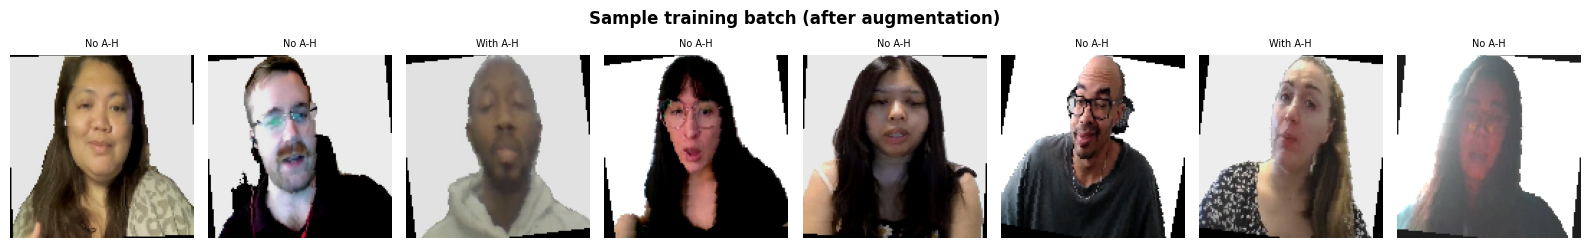

In [16]:
aug = CFG['augmentation']

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5 if aug['random_horizontal_flip'] else 0.0),
    transforms.RandomRotation(aug['random_rotation_degrees']),
    transforms.ColorJitter(
        brightness = aug['color_jitter_brightness'],
        contrast   = aug['color_jitter_contrast'],
        saturation = aug['color_jitter_saturation'],
        hue        = aug['color_jitter_hue'],
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMG_MEAN, std=IMG_STD),
])

eval_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMG_MEAN, std=IMG_STD),
])

train_ds = SegmentedFrameDataset('train', transform=train_transform)
val_ds   = SegmentedFrameDataset('val',   transform=eval_transform)
test_ds  = SegmentedFrameDataset('test',  transform=eval_transform)

# persistent_workers requires num_workers > 0; pin_memory only helps with CUDA
_pw = NUM_WORKERS > 0
_pm = DEVICE.type == 'cuda'

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=_pm, persistent_workers=_pw, drop_last=True,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=_pm, persistent_workers=_pw,
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=_pm, persistent_workers=_pw,
)

print(f'Train batches : {len(train_loader):,}')
print(f'Val   batches : {len(val_loader):,}')
print(f'Test  batches : {len(test_loader):,}')

# ── Sanity-check: show 8 sample images from train ────────────────────────────
imgs, labels = next(iter(train_loader))
print(f'Batch shape: {imgs.shape}  |  Labels sample: {labels[:8].tolist()}')

def denorm(t):
    mean = torch.tensor(IMG_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMG_STD).view(3, 1, 1)
    return (t * std + mean).clamp(0, 1)

fig, axes = plt.subplots(1, 8, figsize=(16, 2.5))
for i, ax in enumerate(axes):
    img_np = denorm(imgs[i]).permute(1, 2, 0).numpy()
    ax.imshow(img_np)
    ax.set_title(CLASS_NAMES[labels[i].item()], fontsize=7)
    ax.axis('off')
plt.suptitle('Sample training batch (after augmentation)', fontweight='bold')
plt.tight_layout()
plt.show()


In [17]:
m = CFG['model']

model = ViT(
    image_size  = IMAGE_SIZE,
    patch_size  = PATCH_SIZE,
    num_classes = NUM_CLASSES,
    dim         = m['dim'],
    depth       = m['depth'],
    heads       = m['heads'],
    mlp_dim     = m['mlp_dim'],
    dropout     = m['dropout'],
    emb_dropout = m['emb_dropout'],
    pool        = m['pool'],
    channels    = CFG['image']['channels'],
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'ViT total params    : {total_params:,}')
print(f'ViT trainable params: {trainable_params:,}')

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)

sched_name = CFG['training']['scheduler']
if sched_name == 'cosine':
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=EPOCHS, eta_min=LR * 1e-2
    )
elif sched_name == 'step':
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer, step_size=max(1, EPOCHS // 3), gamma=0.1
    )
else:
    scheduler = None

print(f'Optimizer : AdamW  lr={LR}  wd={WD}')
print(f'Scheduler : {sched_name}')


ViT total params    : 4,947,714
ViT trainable params: 4,947,714
Optimizer : AdamW  lr=0.0003  wd=0.0001
Scheduler : cosine


In [18]:
def compute_metrics(y_true, y_pred):
    return {
        'acc'      : accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall'   : recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1'       : f1_score(y_true, y_pred, average='macro', zero_division=0),
    }


def run_epoch(loader, model, criterion, optimizer=None, desc=''):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    pbar = tqdm(loader, desc=desc, leave=False, unit='batch')
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for imgs, labels in pbar:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits = model(imgs)
            loss   = criterion(logits, labels)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(labels)
            all_preds.extend(logits.argmax(1).cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
            pbar.set_postfix(loss=f'{loss.item():.4f}')

    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, compute_metrics(all_labels, all_preds)


WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

history     = defaultdict(list)
best_val_f1 = -1.0
no_improve  = 0

header = (
    f"{'Epoch':>6} {'TrLoss':>8} {'TrAcc':>7} {'TrF1':>7} "
    f"{'VaLoss':>8} {'VaAcc':>7} {'VaPrec':>8} {'VaRec':>7} {'VaF1':>7} {'LR':>10}"
)
print(f'Starting training for {EPOCHS} epochs on {DEVICE}...')
print('─' * len(header))
print(header)
print('─' * len(header))

epoch_bar = tqdm(range(1, EPOCHS + 1), desc='Epochs', unit='epoch')
for epoch in epoch_bar:
    tr_loss, tr_m = run_epoch(train_loader, model, criterion, optimizer,
                              desc=f'Ep {epoch}/{EPOCHS} train')
    va_loss, va_m = run_epoch(val_loader,   model, criterion,
                              desc=f'Ep {epoch}/{EPOCHS} val  ')
    epoch_bar.set_postfix(val_f1=f'{va_m["f1"]:.4f}', val_acc=f'{va_m["acc"]:.4f}')

    if scheduler is not None:
        scheduler.step()

    cur_lr = optimizer.param_groups[0]['lr']

    history['epoch'].append(epoch)
    history['tr_loss'].append(tr_loss)
    history['va_loss'].append(va_loss)
    history['lr'].append(cur_lr)
    for k, v in tr_m.items():
        history[f'tr_{k}'].append(v)
    for k, v in va_m.items():
        history[f'va_{k}'].append(v)

    print(
        f"{epoch:>6} {tr_loss:>8.4f} {tr_m['acc']:>7.4f} {tr_m['f1']:>7.4f} "
        f"{va_loss:>8.4f} {va_m['acc']:>7.4f} {va_m['precision']:>8.4f} "
        f"{va_m['recall']:>7.4f} {va_m['f1']:>7.4f} {cur_lr:>10.2e}"
    )

    if va_m['f1'] > best_val_f1:
        best_val_f1 = va_m['f1']
        torch.save(model.state_dict(), WEIGHTS_DIR / WEIGHTS_NAME)
        print(f'  New best val F1={best_val_f1:.4f} — saved {WEIGHTS_NAME}')
        no_improve = 0
    else:
        no_improve += 1

    if PATIENCE > 0 and no_improve >= PATIENCE:
        print(f'Early stopping after {epoch} epochs (patience={PATIENCE})')
        break

print('─' * len(header))
print(f'Training complete.  Best val F1 = {best_val_f1:.4f}')

if SAVE_LAST:
    torch.save(model.state_dict(), WEIGHTS_DIR / LAST_NAME)
    print(f'Last-epoch weights saved -> {WEIGHTS_DIR / LAST_NAME}')

# ── Plot training curves ──────────────────────────────────────────────────────
hist = pd.DataFrame(history)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].plot(hist['epoch'], hist['tr_loss'], label='Train')
axes[0, 0].plot(hist['epoch'], hist['va_loss'], label='Val')
axes[0, 0].set_title('Loss')
axes[0, 0].legend()
axes[0, 0].set_xlabel('Epoch')

axes[0, 1].plot(hist['epoch'], hist['tr_acc'], label='Train')
axes[0, 1].plot(hist['epoch'], hist['va_acc'], label='Val')
axes[0, 1].set_title('Accuracy')
axes[0, 1].legend()
axes[0, 1].set_xlabel('Epoch')

axes[1, 0].plot(hist['epoch'], hist['tr_f1'], label='Train')
axes[1, 0].plot(hist['epoch'], hist['va_f1'], label='Val')
axes[1, 0].set_title('F1 (macro)')
axes[1, 0].legend()
axes[1, 0].set_xlabel('Epoch')

axes[1, 1].plot(hist['epoch'], hist['va_precision'], label='Precision')
axes[1, 1].plot(hist['epoch'], hist['va_recall'],    label='Recall')
axes[1, 1].plot(hist['epoch'], hist['va_f1'],        label='F1')
axes[1, 1].set_title('Val Precision / Recall / F1')
axes[1, 1].legend()
axes[1, 1].set_xlabel('Epoch')

for ax in axes.flat:
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(alpha=0.3)

plt.suptitle('Training history', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Starting training for 20 epochs on mps...
────────────────────────────────────────────────────────────────────────────────────
 Epoch   TrLoss   TrAcc    TrF1   VaLoss   VaAcc   VaPrec   VaRec    VaF1         LR
────────────────────────────────────────────────────────────────────────────────────


Epochs:   5%|▌         | 1/20 [07:16<2:18:05, 436.06s/epoch, val_acc=0.8241, val_f1=0.4518]

     1   0.4257  0.8481  0.4589   0.4762  0.8241   0.4120  0.5000  0.4518   2.98e-04
  New best val F1=0.4518 — saved vit_bah_best.pth


Epochs:  10%|█         | 2/20 [14:56<2:15:06, 450.36s/epoch, val_acc=0.8241, val_f1=0.4518]

     2   0.4181  0.8481  0.4612   0.5074  0.8241   0.4120  0.5000  0.4518   2.93e-04


Epochs:  15%|█▌        | 3/20 [22:21<2:06:55, 447.99s/epoch, val_acc=0.8239, val_f1=0.4517]

     3   0.4169  0.8481  0.4621   0.4875  0.8239   0.4120  0.4999  0.4517   2.84e-04


Epochs:  15%|█▌        | 3/20 [23:24<2:12:36, 468.01s/epoch, val_acc=0.8239, val_f1=0.4517]


KeyboardInterrupt: 

In [ ]:
# ── Load best weights ─────────────────────────────────────────────────────────
best_ckpt = WEIGHTS_DIR / WEIGHTS_NAME
model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))
print(f'Loaded best weights from {best_ckpt}')

# ── Inference ─────────────────────────────────────────────────────────────────
model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc='Test inference'):
        imgs   = imgs.to(DEVICE)
        logits = model(imgs)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()
        preds  = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.numpy().tolist())
        all_probs.extend(probs.tolist())

# ── Metrics ───────────────────────────────────────────────────────────────────
test_m = compute_metrics(all_labels, all_preds)

print()
print('=' * 50)
print('TEST SET METRICS')
print('=' * 50)
print(f"  Accuracy  : {test_m['acc']:.4f}")
print(f"  Precision : {test_m['precision']:.4f}  (macro)")
print(f"  Recall    : {test_m['recall']:.4f}  (macro)")
print(f"  F1        : {test_m['f1']:.4f}  (macro)")
print()
print('Per-class report:')
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4))

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES)
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix — Test Set', fontweight='bold')
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, f'{cm[i, j]:,}', ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=12)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


In [ ]:
# Best weights were already saved during training whenever val F1 improved.
# This cell provides an explicit final save of the current model state and
# prints a summary of all saved artefacts.

WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

# Save current (last) state explicitly regardless of SAVE_LAST flag
final_path = WEIGHTS_DIR / LAST_NAME
torch.save(model.state_dict(), final_path)
print(f'Final weights saved -> {final_path}')

# Also save a full checkpoint with optimizer state for resuming
checkpoint = {
    'epoch'      : epoch,
    'model_state': model.state_dict(),
    'optim_state': optimizer.state_dict(),
    'best_val_f1': best_val_f1,
    'config'     : CFG,
}
ckpt_path = WEIGHTS_DIR / 'checkpoint_last.pth'
torch.save(checkpoint, ckpt_path)
print(f'Full checkpoint saved -> {ckpt_path}')

print()
print('Saved artefacts:')
for p in sorted(WEIGHTS_DIR.iterdir()):
    size_mb = p.stat().st_size / 1024 / 1024
    print(f'  {p.name:<40}  {size_mb:>7.2f} MB')
